# Import the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import xskillscore as xs
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import dill
import gc

2026-06-16 12:24:01.957368: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781605442.200992    2111 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781605442.271243    2111 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781605442.752715    2111 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781605442.752851    2111 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781605442.752857    2111 computation_placer.cc:177] computation placer alr

# Upload file pickle

In [2]:
with open('cnn_obs.pkl', 'rb') as file:
    hadisst_dic = dill.load(file)
    ncep_ncar_dic = dill.load(file)

In [3]:
with open('results_per_leadtime.pkl', 'rb') as file:
    results_per_leadtime = dill.load(file)

# Define the months for the CNN input; define the number of lead time

In [4]:
months_name = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG']
number_lead_time = 6

# Plot of Training and Validation loss

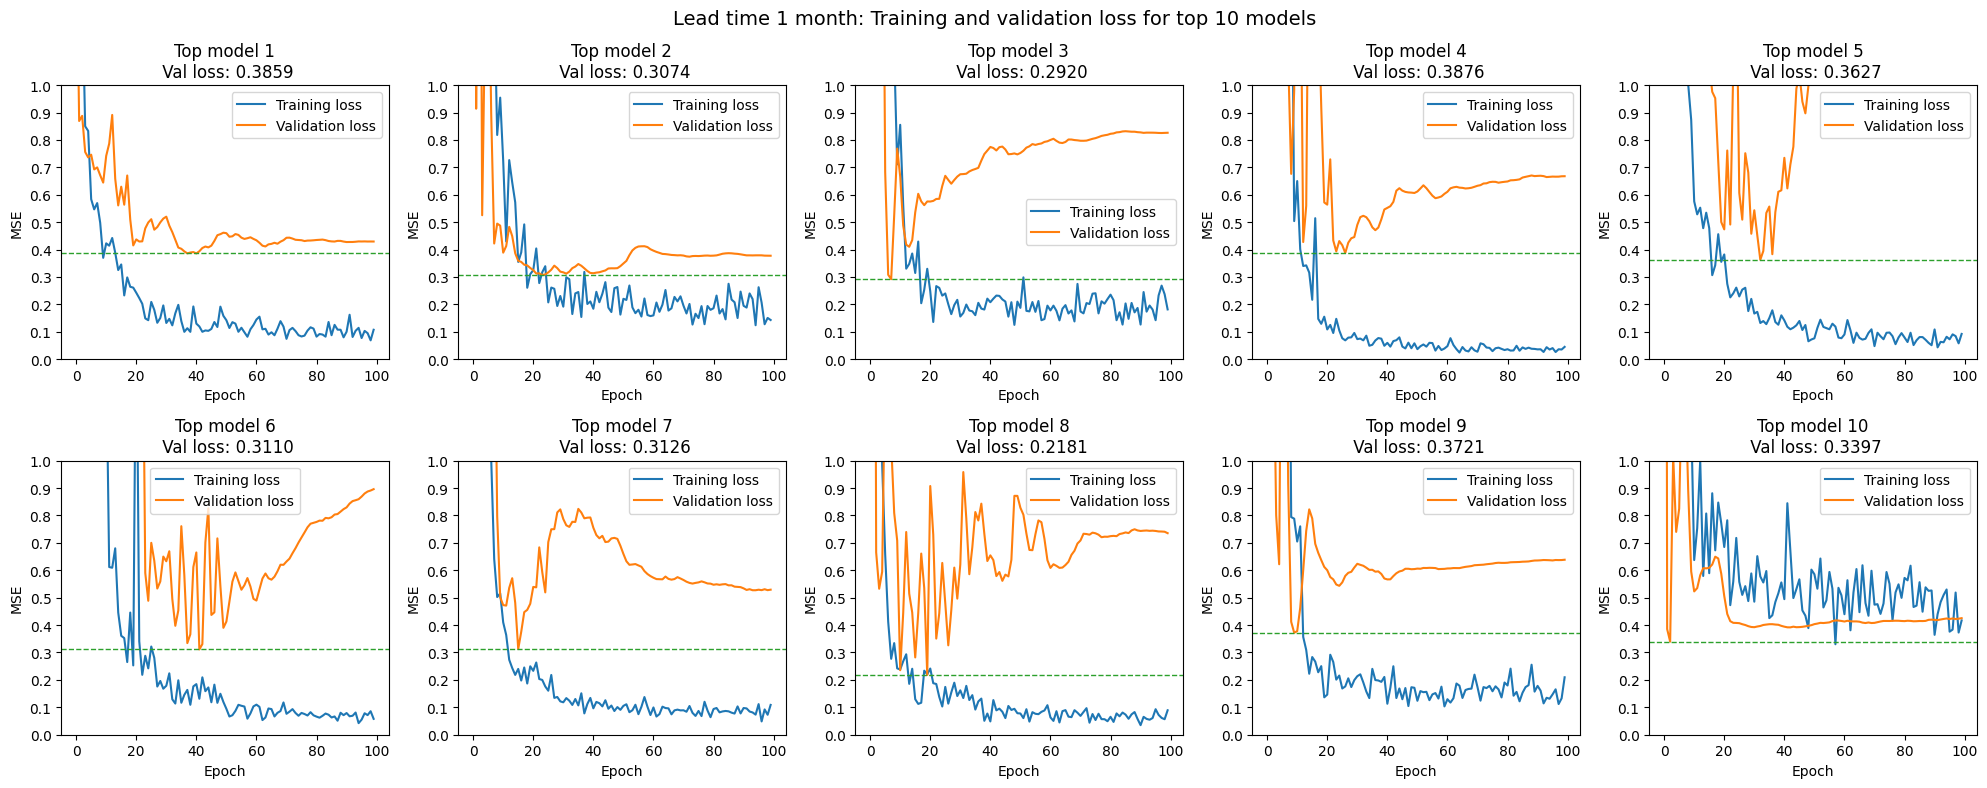

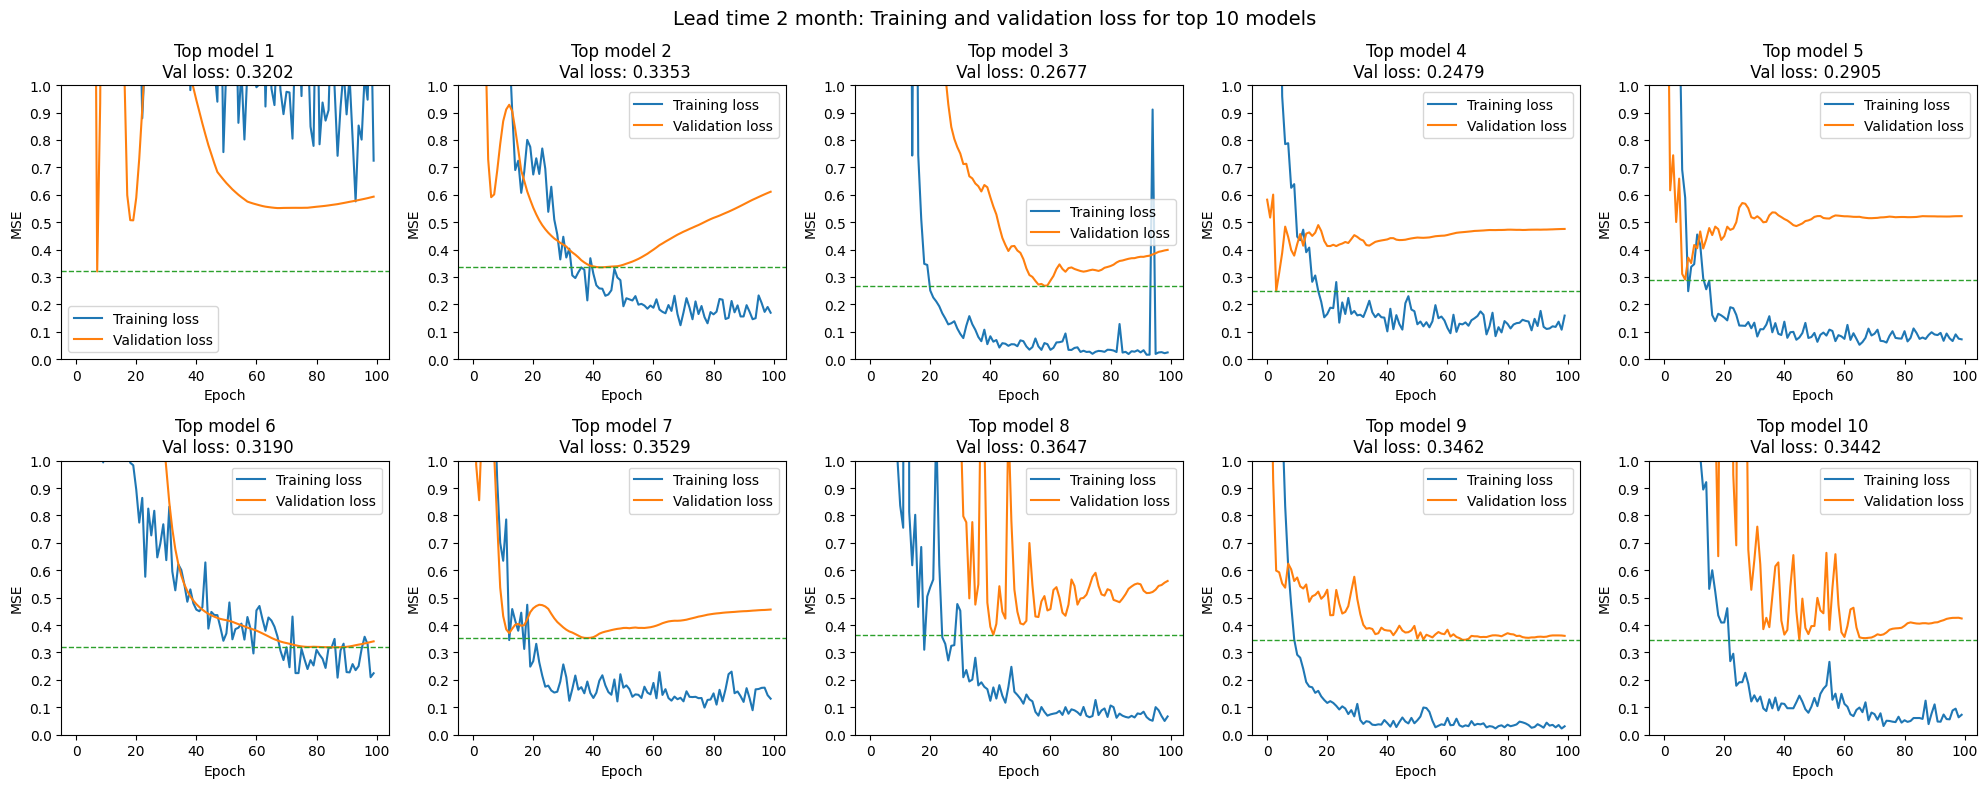

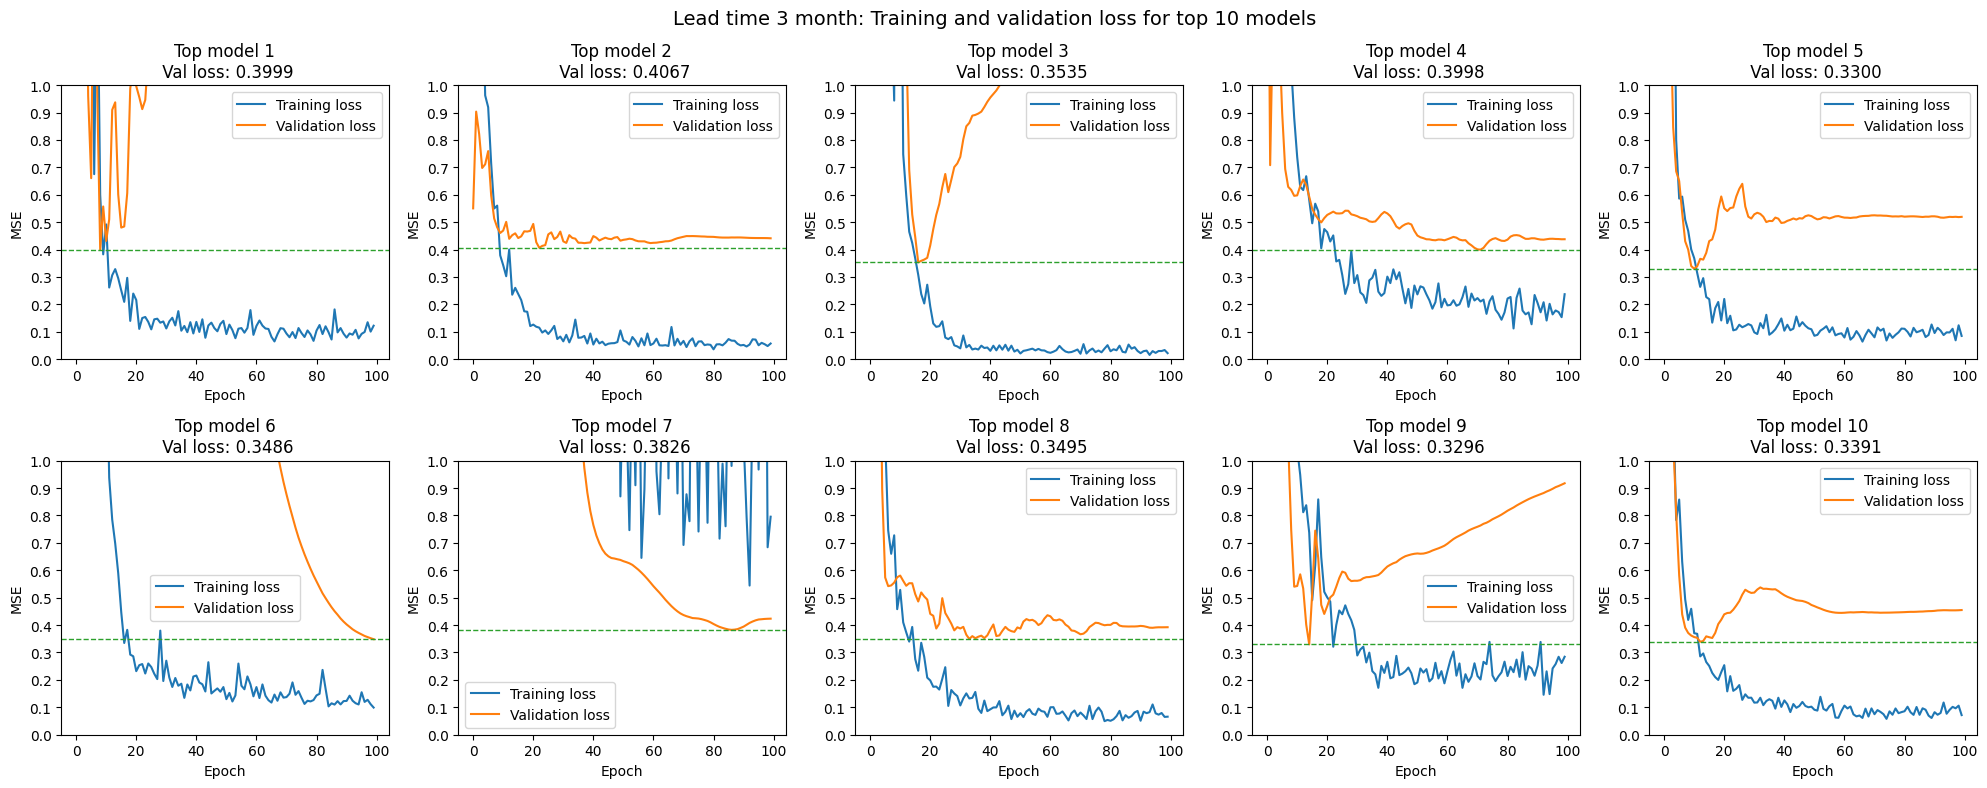

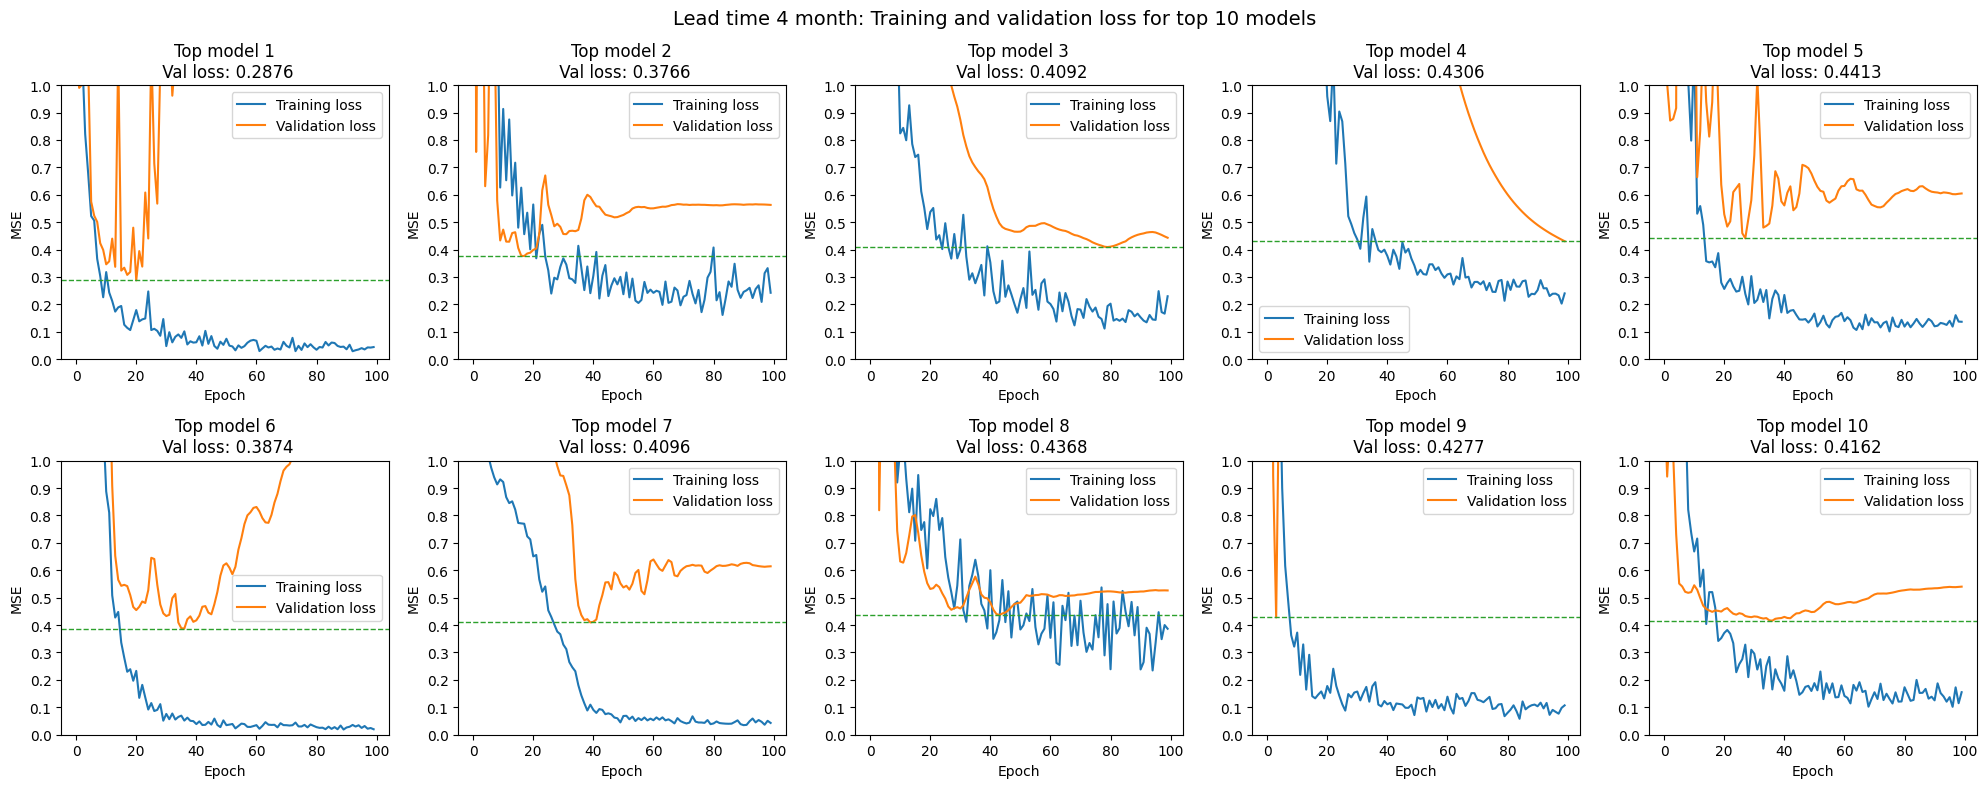

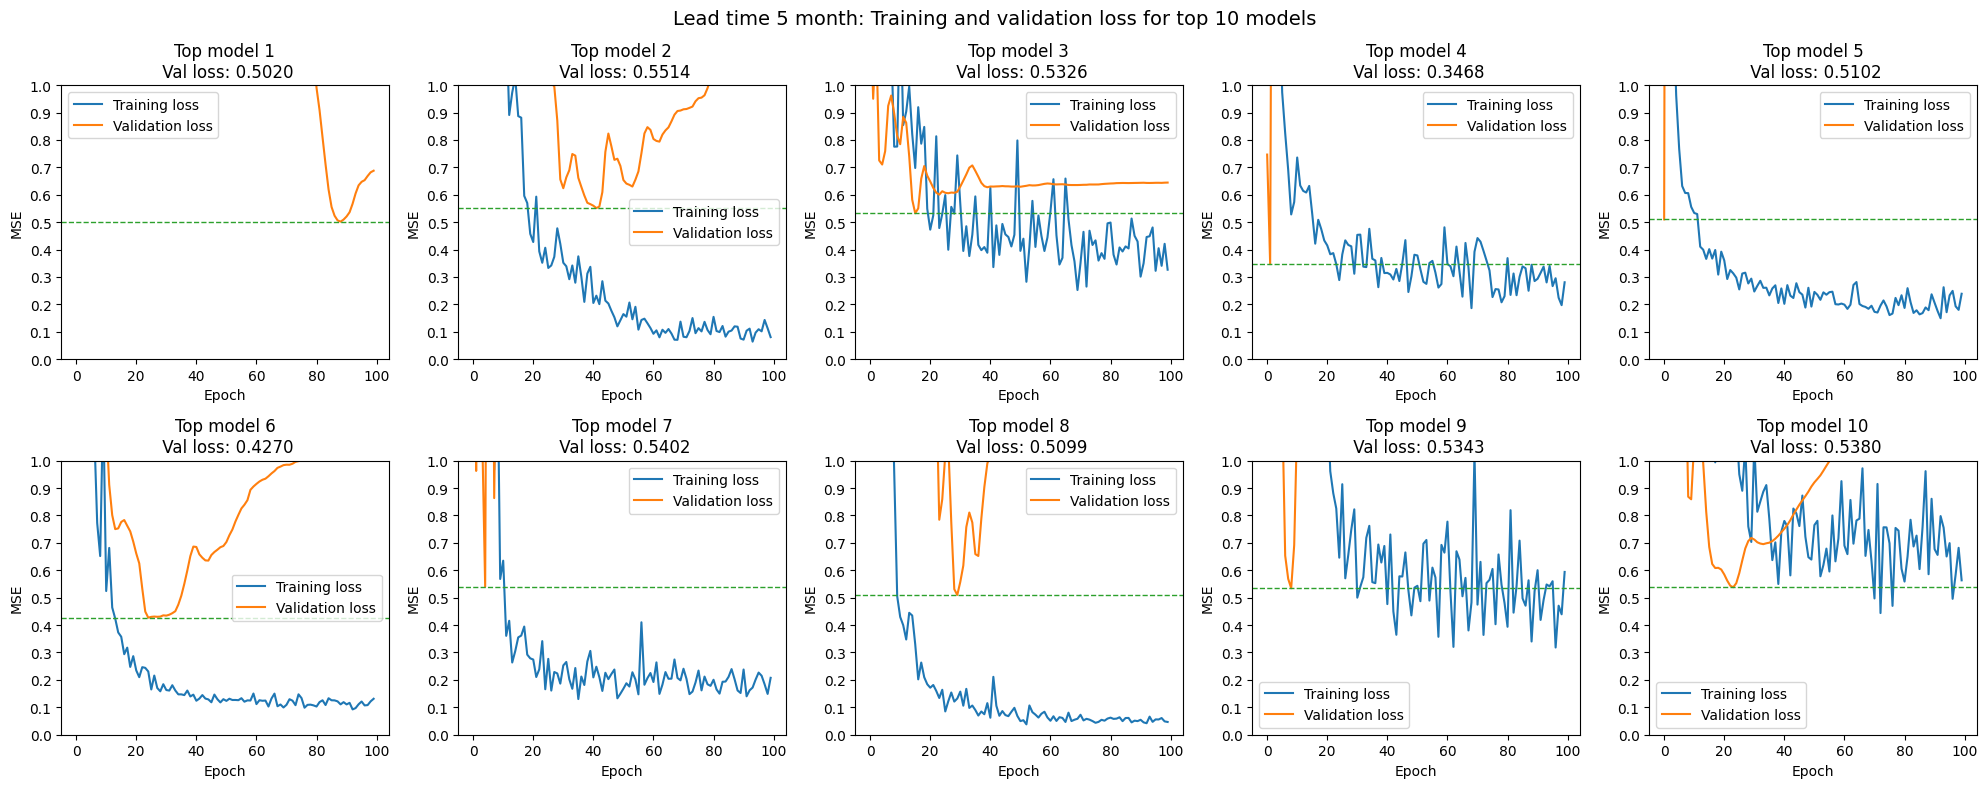

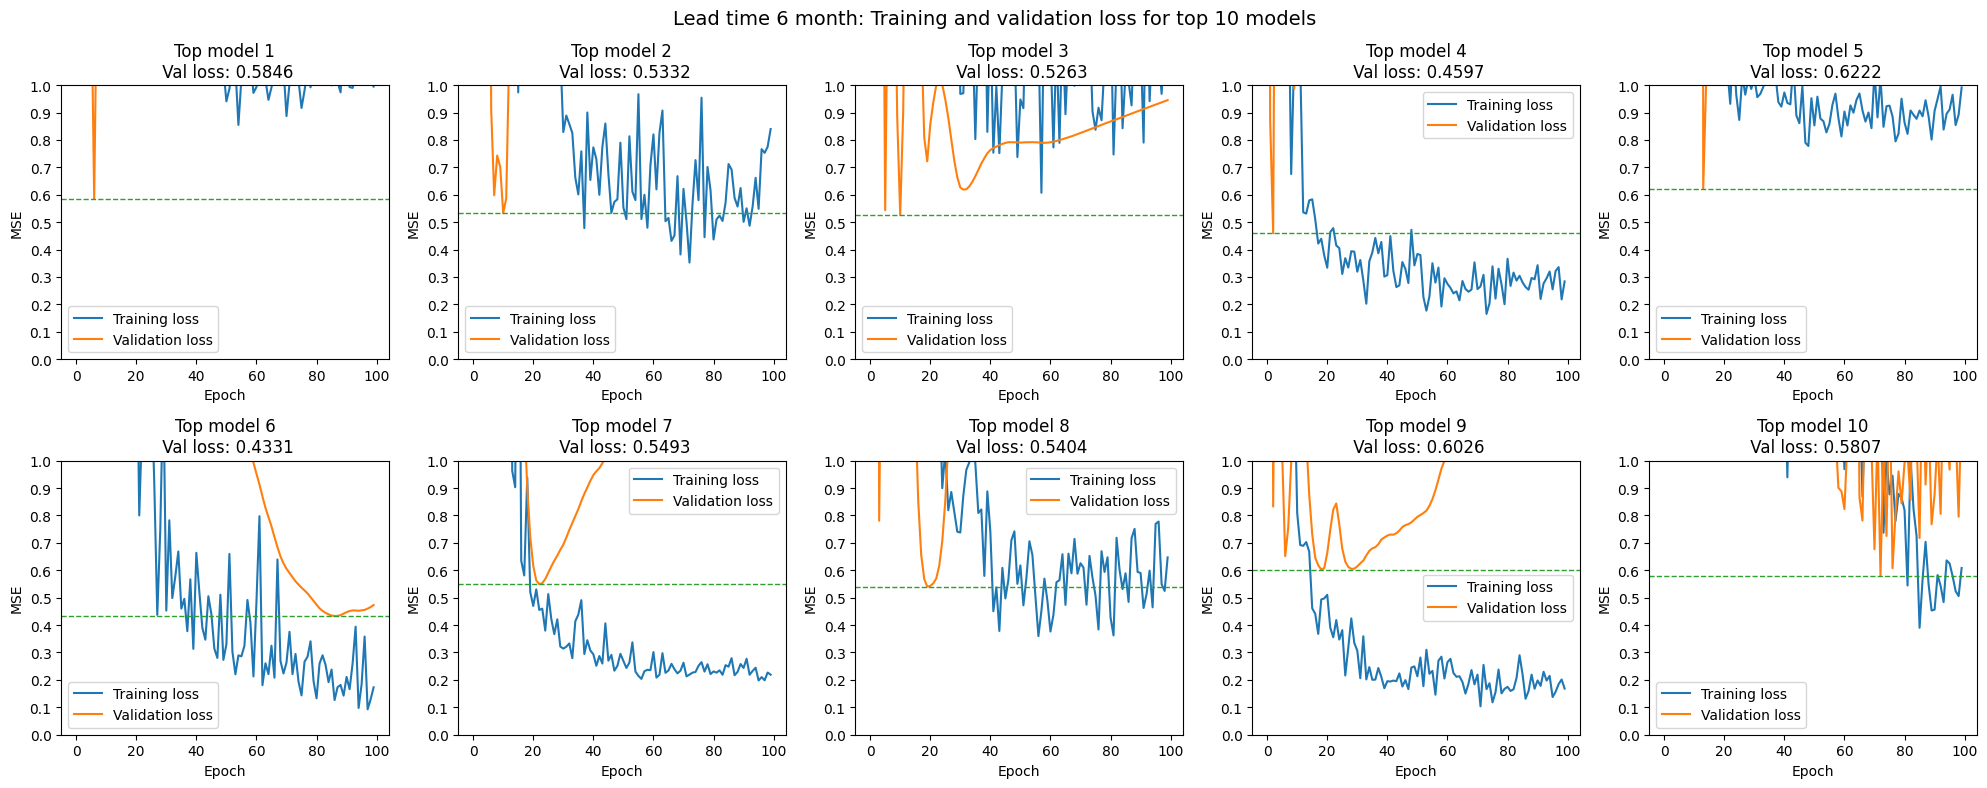

In [5]:
#Plot of training loss and validation loss as the learning rate increases
#The minimum validation loss is the chosen one
for j in range(1,number_lead_time+1):
    top_histories = results_per_leadtime[j]['top_histories']
    top_scores = results_per_leadtime[j]['top_scores']
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for i, (hist, ax) in enumerate(zip(top_histories, axes)):
        ax.plot(hist['loss'], label='Training loss', color='C0')
        ax.plot(hist['val_loss'], label='Validation loss', color='C1')
        ax.axhline(top_scores[i],linewidth=1, linestyle='--',color='C2')
        ax.set_ylim(0,1)
        ax.set_xticks(np.arange(0,110,20))
        ax.set_yticks(np.arange(0,1.05,0.1))
        ax.set_title(f'Top model {i+1}\n Val loss: {top_scores[i]:.4f}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE')
        ax.legend(loc='best')

    plt.suptitle(f'Lead time {j} month: Training and validation loss for top 10 models', fontsize=14)
    plt.tight_layout()
    plt.show()
    if j == 1: #for the lead time 1 save the plot in a pdf format
        fig.savefig('train_val_loss.pdf', format='pdf')

# Performance metrics on training and validation

In [12]:
#Reconstruct the best 10 predictions models on training and validation to compute the performance metrics

for j in range(1,number_lead_time+1):

    #TRAINING DATA
    X_train = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly training'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly training']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_train = hadisst_dic['SON (di west-east)']['dipole index training'].fillna(0)
    
    #VALIDATION DATA
    X_val = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation'], #SST
                      ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly validation'], #SLP
                      ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly validation']], #SLP
                      dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')
    y_val = hadisst_dic['SON (di west-east)']['dipole index validation'].fillna(0)
    
    X_train_tensor = tf.constant(X_train.values.astype('float32'))
    y_train_np = y_train.values.astype('float32')
    X_val_tensor = tf.constant(X_val.values.astype('float32'))
    y_val_np = y_val.values.astype('float32')
    
    final_train_predictions = []
    final_val_predictions = []

    for weights, params in zip(results_per_leadtime[j]['top_models_weights'], results_per_leadtime[j]['top_models_params']):
        tf.keras.backend.clear_session()

        # Same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']
        # First block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_train_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Second block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        filters *= 2
        dropout += 0.1
        # Third block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_train_tensor[:1], verbose=0)
        model.set_weights(weights)

        final_train_predictions.append(model.predict(X_train_tensor, verbose=0))
        final_val_predictions.append(model.predict(X_val_tensor, verbose=0))
        
        del model
        tf.keras.backend.clear_session()
        gc.collect()

    results_per_leadtime[j]['final_train_predictions'] = final_train_predictions
    results_per_leadtime[j]['final_val_predictions'] = final_val_predictions

2026-06-15 10:53:42.434548: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Function to compute the performance metrics
def print_metrics_single_leadtime(prediction, target, name_train_val_test, lead_time_index):
    mae = xs.mae(prediction, target, dim='time').values
    mse = xs.mse(prediction, target, dim='time').values
    rmse = xs.rmse(prediction, target, dim='time').values
    corr = xs.pearson_r(prediction, target, dim='time').values
    r2 = xs.r2(prediction, target, dim='time').values

    print(f"{name_train_val_test} - Lead time {lead_time_index}: "
          f"MAE: {mae:.4f}; "
          f"MSE: {mse:.4f}; "
          f"RMSE: {rmse:.4f}; "
          f"Pearson ACC: {corr:.4f}; "
          f"R²: {r2:.4f}")

for j in range(len(results_per_leadtime)):
    ensemble_train = np.mean(results_per_leadtime[j+1]['final_train_predictions'], axis=0)
    ensemble_val = np.mean(results_per_leadtime[j+1]['final_val_predictions'], axis=0)

    ensemble_train = xr.DataArray(ensemble_train.squeeze(), dims=('time'), coords={'time': y_train.time})
    ensemble_val = xr.DataArray(ensemble_val.squeeze(), dims=('time'), coords={'time': y_val.time})
    
    results_per_leadtime[j+1]['ensemble_train'] = ensemble_train
    results_per_leadtime[j+1]['ensemble_val'] = ensemble_val
    
    print_metrics_single_leadtime(ensemble_train, y_train, 'TRAINING', j+1)
    print_metrics_single_leadtime(ensemble_val, y_val, 'VALIDATION', j+1)
    print("-" * 50) # Separator line for readability

TRAINING - Lead time 1: MAE: 0.4812; MSE: 0.2720; RMSE: 0.5215; Pearson ACC: 0.9780; R²: 0.6906
VALIDATION - Lead time 1: MAE: 0.3857; MSE: 0.1999; RMSE: 0.4471; Pearson ACC: 0.8836; R²: 0.6310
--------------------------------------------------
TRAINING - Lead time 2: MAE: 0.3033; MSE: 0.1239; RMSE: 0.3520; Pearson ACC: 0.9847; R²: 0.8202
VALIDATION - Lead time 2: MAE: 0.3561; MSE: 0.2242; RMSE: 0.4735; Pearson ACC: 0.8940; R²: 0.4320
--------------------------------------------------
TRAINING - Lead time 3: MAE: 0.4047; MSE: 0.2357; RMSE: 0.4855; Pearson ACC: 0.9418; R²: 0.7276
VALIDATION - Lead time 3: MAE: 0.3938; MSE: 0.2603; RMSE: 0.5102; Pearson ACC: 0.8548; R²: 0.3505
--------------------------------------------------
TRAINING - Lead time 4: MAE: 0.3775; MSE: 0.2065; RMSE: 0.4545; Pearson ACC: 0.9574; R²: 0.7788
VALIDATION - Lead time 4: MAE: 0.3431; MSE: 0.2180; RMSE: 0.4670; Pearson ACC: 0.9186; R²: 0.3400
--------------------------------------------------
TRAINING - Lead time

# Testing of the CNN

In [14]:
results_per_leadtime_testing = {}

for j in range(1,number_lead_time+1):
    # TESTING DATA
    X_test = xr.concat([hadisst_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        hadisst_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing'], #SST
                        ncep_ncar_dic[f'{months_name[-j]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-1]} (Indian Pacific oceans)']['standardized anomaly testing'], #SLP
                        ncep_ncar_dic[f'{months_name[-j-2]} (Indian Pacific oceans)']['standardized anomaly testing']], #SLP
                        dim='channels').fillna(0).transpose('time', 'lat', 'lon', 'channels')  # (23, 21, 61, 1)
    y_test = hadisst_dic['SON (di west-east)']['dipole index testing'].fillna(0)
    
    X_test_tensor = tf.constant(X_test.values.astype('float32'))
    y_test_np = y_test.values.astype('float32')
    
    # Reconstruct the top 10 models and 'validate' them on test set
    final_test_predictions = []

    for i, (weights, params) in enumerate(zip(results_per_leadtime[j]['top_models_weights'], results_per_leadtime[j]['top_models_params'])):
        
        tf.keras.backend.clear_session()

        # Reconstruct the same architecture
        model = models.Sequential()
        filters = params['initial_filters']
        dropout = params['initial_dropout']

        # First Conv Block
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', input_shape=X_test_tensor.shape[1:], padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Second Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        # Third Conv Block
        filters *= 2
        dropout += 0.1
        model.add(layers.Conv2D(filters=filters, kernel_size=params['filter_size'], activation='elu', padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))

        model.add(layers.Flatten())
        model.add(layers.Dense(params['dense_units'], activation='elu'))
        model.add(layers.Dense(1))

        model.compile(optimizer=optimizers.Adam(learning_rate=params['learning_rate']), loss='mse', metrics=['mae'])
        model.predict(X_test_tensor[:1], verbose=0) #It serves as initialization
        
        # Upload weights saved during the training
        model.set_weights(weights)
        # Prediction on test set
        pred = model.predict(X_test_tensor, verbose=0)
        final_test_predictions.append(pred)

        test_loss, test_mae = model.evaluate(X_test_tensor, y_test_np, verbose=0)
        print(f"Model {i+1} — test MSE: {test_loss:.4f}, test MAE: {test_mae:.4f}")

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    # Final Ensemble for each lead time: mean of the top 10 models
    ensemble_prediction = np.mean(final_test_predictions, axis=0)
    ensemble_prediction = xr.DataArray(ensemble_prediction.squeeze(), dims=('time'),
                                coords={'time': y_test.time})
    results_per_leadtime_testing[j] = {'ensemble_prediction': ensemble_prediction}

/home/sarabeltrami9/myenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 — test MSE: 1.3434, test MAE: 1.0677
Model 2 — test MSE: 1.0200, test MAE: 0.8738
Model 3 — test MSE: 0.8759, test MAE: 0.7604
Model 4 — test MSE: 1.1577, test MAE: 0.7015
Model 5 — test MSE: 0.7621, test MAE: 0.7067
Model 6 — test MSE: 0.2116, test MAE: 0.3693
Model 7 — test MSE: 0.1880, test MAE: 0.3185
Model 8 — test MSE: 0.6901, test MAE: 0.6891
Model 9 — test MSE: 0.8131, test MAE: 0.7198
Model 10 — test MSE: 0.6401, test MAE: 0.6801
Model 1 — test MSE: 0.3415, test MAE: 0.4898
Model 2 — test MSE: 0.5702, test MAE: 0.6100
Model 3 — test MSE: 0.5499, test MAE: 0.6445
Model 4 — test MSE: 0.6011, test MAE: 0.6399
Model 5 — test MSE: 0.3657, test MAE: 0.5443
Model 6 — test MSE: 0.9742, test MAE: 0.8017
Model 7 — test MSE: 0.6129, test MAE: 0.6107
Model 8 — test MSE: 0.5049, test MAE: 0.5958
Model 9 — test MSE: 0.3213, test MAE: 0.5192
Model 10 — test MSE: 0.9028, test MAE: 0.8924
Model 1 — test MSE: 0.5192, test MAE: 0.6788
Model 2 — test MSE: 1.4684, test MAE: 1.0818
Model 3 

## Performance metrics for test set

In [15]:
for j in range(len(results_per_leadtime_testing)):
    print_metrics_single_leadtime(results_per_leadtime_testing[j+1]['ensemble_prediction'], y_test, 'TESTING', j+1)
    print("-" * 50) # Separator line for readability

TESTING - Lead time 1: MAE: 0.5452; MSE: 0.4356; RMSE: 0.6600; Pearson ACC: 0.7424; R²: -1.2848
--------------------------------------------------
TESTING - Lead time 2: MAE: 0.4974; MSE: 0.2923; RMSE: 0.5406; Pearson ACC: 0.8121; R²: -1.6638
--------------------------------------------------
TESTING - Lead time 3: MAE: 0.7812; MSE: 0.8384; RMSE: 0.9156; Pearson ACC: 0.2415; R²: -1.7263
--------------------------------------------------
TESTING - Lead time 4: MAE: 0.8200; MSE: 0.8065; RMSE: 0.8981; Pearson ACC: -0.5304; R²: -20.6665
--------------------------------------------------
TESTING - Lead time 5: MAE: 0.7174; MSE: 0.7863; RMSE: 0.8867; Pearson ACC: 0.1736; R²: -2.3202
--------------------------------------------------
TESTING - Lead time 6: MAE: 0.6058; MSE: 0.5340; RMSE: 0.7308; Pearson ACC: 0.4053; R²: -16.5089
--------------------------------------------------


# Save the results in a file pickle

In [16]:
with open('ensemble_prediction.pkl', 'wb') as file:
    dill.dump(results_per_leadtime_testing, file)